# Reinforcement Learning In PyWorld3-03 With Some Control Functions

**Authors of this modified file:** Evelina Örsvik and Linnea Stålberg

**Date of modifications:** March 2026

**Note on original authors:** This file is an adaptation of Emil Johansson and Linnéa Bäckvall's reinforcement learning file `reinforcementLearning.ipynb` available at https://github.com/emilj610/pyworld3A3. It has been modified to fit our (the authors') purposes.

*We have also referred to lecture notes in the KTH course DD1420 as well as documentation of relevant libraries, [PyTorch beginner tutorials](https://docs.pytorch.org/tutorials/beginner/basics/intro.html), World3 literature and the bachelor thesis report of Emil Johansson and Linnéa Bäckvall.*

The goal is to train a neural network to approximate a cumulative reward function $J$ with the approximation $\hat J$. Then we try to find better controls than used for the standard run (using $\hat J$ as the objective function to optimise) by doing a grid search.

Running this file successfully requires having training data first. Training data can be obtained by running `data_generation.py`.

The disposition of the file is the following:

1.  Initial setup
2.  Data extraction and training of neural network
3.  Optimization
4.  Plot results

## Initial setup

Import libraries, define some constants, initialise a standard run of World3-03, and define reward function(s).

In [1]:
# Imports

# General, used throughout the file
import numpy as np
from pyworld3 import World3
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm # used for progress bar

# For nn training
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Special plotting
from pyworld3.utils import plot_world_variables

In [2]:
# Define constants to be used throughout the file
MIN_YEAR = 1900
MAX_YEAR = 2100

In [ ]:
# Standard run until MAX_YEAR
world_reference = World3(year_min=MIN_YEAR, year_max=MAX_YEAR)
world_reference.set_world3_control()
world_reference.init_world3_constants()
world_reference.init_world3_variables()
world_reference.set_world3_table_functions()
world_reference.set_world3_delay_functions()
world_reference.run_world3(fast=False) # want to be able to set fast=True

nrur 0:
282625000.00000006
nr 0:
1000000000000.0


Here we define the Human Welfare Index (built into World3-03) as the reward function, $g$. Most likely we will also define other reward functions in the future.

In [4]:
def reward_hwi(world, k=None):
    """
    Input:
        world   -   the World3 object to get reward from
        k       -   int representing a time step (optional)
    Output:
        if k=None, a vector with hwi values; otherwise the hwi at step k
    """
    reward = world.hwi
    if k is None:
        return reward
    else:
        return reward[k]

## Data extraction and training of neural network

In this section we extract the data from its storage, preprocess it, and use it to train a neural network. We also plot the loss. The disposition of this section is as follows:

1.  Data extraction and setup
2.  Preprocessing
3.  Training and creating a function
4.  Loss comparison

### Data extraction and setup

Running this requires a file with training data. Training data should include cumulative rewards $J$ (throughout each run) and state variables (throughout each run) stored for runs with randomised initial values.

In [ ]:
filepath = "datasets/data_reward_hwi.parquet" # where training data is stored
df = pd.read_parquet(filepath)
state_variables = df.columns[df.columns != "J"]
no_init_vars = ["pcrum", "time"] # specify which variables are not "initialable"

reward_name = "HWI"
reward_func = reward_hwi # select which reward function to use, will be used throughout the file

Define a neural network class (requires imports from PyTorch and scikit-learn, imported in the beginning of this file). Use two hidden layers and ReLU activation ($\text{act}(z)=\max(0, z)$) throughout the forward pass. Note that `nn.Module` is a base class that our class `neuralNet` builds upon.

In [6]:
class neuralNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        # 2 hidden layers
        super(neuralNet, self).__init__()
        self.input_layer = nn.Linear(in_features=in_dim, out_features=32)
        self.hidden_layer1 = nn.Linear(in_features=32, out_features=64) 
        self.hidden_layer2 = nn.Linear(in_features=64, out_features=32)
        self.outLayer = nn.Linear(in_features=32, out_features=out_dim)

    def forward(self, x):
        # forward pass with relu activation function
        x = self.input_layer(x)
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = self.outLayer(x)
        return x

### Preprocessing

Here we preprocess the data before feeding it to our neural network.

We split the data so that 80% is used for training and 20% for testing. One can change these proportions by modifying `test_size` in `train_test_split` call. Selecting `random_state=42` allows us to reproduce results across multiple function calls. For further information see the documentation of `sklearn.model_selection.train_test_split`.

We also normalise the data to increase stability and speed of the neural network.
For $X$ (i.e., state variables) and $J$ (i.e., true reward) separately, we fit a `StandardScaler` to the training data, then transform the data using the mean and standard deviation obtained during fitting. Then we also transform the training data with the same mean and standard deviation (separately for $X$ and $J$).

After normalising the data, we turn it into PyTorch tensors (similar to ndarrays in NumPy).

In [7]:
X = df.drop(columns=["J"]).to_numpy()
J = df["J"].to_numpy().reshape(-1,1)

X_train, X_test, J_train, J_test = train_test_split(X, J, test_size=0.2, random_state=42) # change test_size for different proportion of training/testing data

# normalising
X_normaliser = StandardScaler()
X_train = X_normaliser.fit_transform(X_train)
X_test = X_normaliser.transform(X_test)
J_normaliser = StandardScaler()
J_train = J_normaliser.fit_transform(J_train)
J_test = J_normaliser.transform(J_test)

# turning into pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
J_train = torch.tensor(J_train, dtype=torch.float32)
J_test = torch.tensor(J_test, dtype=torch.float32)

Now `X_train` is a PyTorch tensor with each datapoint stored as a row. So the dimension of one datapoint is `X_train.shape[1]` (number of columns in `X_train`).

### Training and creating a function

Here we create a neural network model using mean squared error (MSE) loss. As an optimiser we use Adam (Adaptive Moment Estimation) built into PyTorch. Further, we use the learning rate 0.001. For details please see the `torch.optim.Adam` documentation and PyTorch tutorials, in particular https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html. We train the NN using the runs (without control functions) with randomised initial state variables (randomised with Gaussian distribution around standard run initial values) that our training data set consists of. The NN is trained to represent the approximative cumulative reward, $\hat J$.

In [8]:
model = neuralNet(X_train.shape[1], 1)
loss_func = nn.MSELoss() 
optimiser = torch.optim.Adam(model.parameters(), lr=0.001) # the method with which the NN optimises the loss function

epochs = 200
losses = np.zeros((epochs,1)) # storage for training losses
test_losses = np.zeros((epochs,1)) # storage for test losses


for epoch in tqdm(range(epochs)):
    model.train() # activate training mode (best practice)

    # Prediction and loss
    J_pred = model.forward(X_train)
    loss = loss_func(J_pred, J_train) # J_train is the true value, J_pred is the predicted value

    # Backpropagation
    optimiser.zero_grad() 
    loss.backward() 
    optimiser.step() 
    losses[epoch] = loss.item() # save training loss

    model.eval() # activate evaluation mode (best practice)
    with torch.no_grad():
        J_pred_test = model.forward(X_test)
        loss_test = loss_func(J_pred_test, J_test)
        test_losses[epoch] = loss_test # save test loss

100%|██████████| 200/200 [00:05<00:00, 35.79it/s]


Plot the training and test losses.

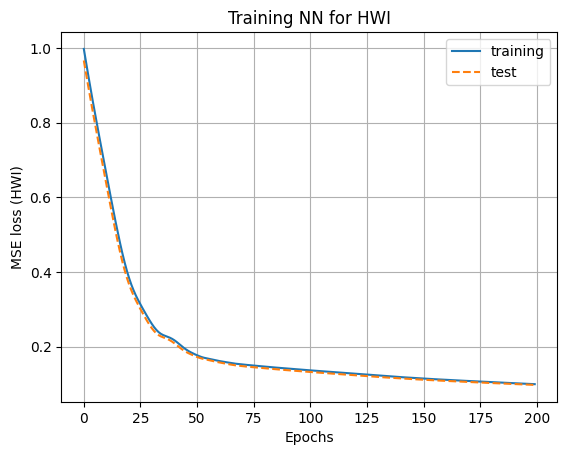

In [9]:
plt.plot(losses, label="training")
plt.plot(test_losses, label="test", linestyle='--')

plt.xlabel("Epochs")
plt.ylabel(f"MSE loss ({reward_name})")
plt.title(f"Training NN for {reward_name}")
plt.legend(), plt.grid(), 
plt.savefig(f"plots/{reward_name}_training")
plt.show()

### Loss comparison

TODO: comment further.

In [10]:
X_numpy = X_normaliser.inverse_transform(X_test.numpy())
J_numpy = J_test.numpy()

time_index = state_variables.get_loc('time')
errors = []
years = []

for year in range(MIN_YEAR, MAX_YEAR, 5):
    condition = (X_numpy[:, time_index] < year+5) & (X_numpy[:, time_index] >= year)  # all rows where the condition is true
    row_indices = np.where(condition)[0]

    X_rows =  X_normaliser.transform(X_numpy[row_indices,:])

    model.eval()
    with torch.no_grad():
        J_pred = model.forward(torch.tensor(X_rows, dtype=torch.float32))
    error = np.sum((J_pred.numpy() - J_numpy[row_indices])**2) / row_indices.size
    errors.append(error)
    years.append(year)

Plot the results.

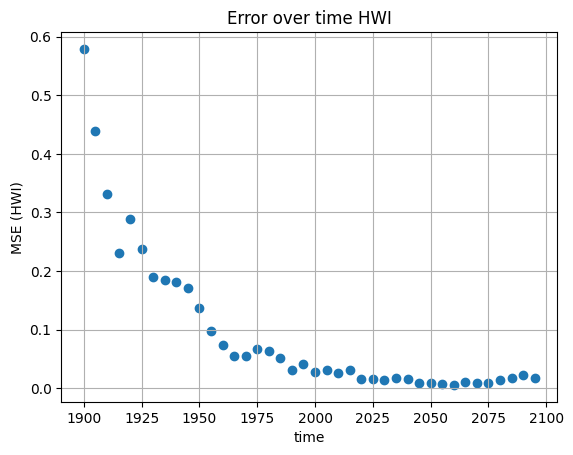

In [11]:
plt.scatter(years, errors)
plt.xlabel("time")
plt.ylabel(f"MSE ({reward_name})")
plt.title(f"Error over time {reward_name}")
plt.grid()
plt.savefig(f"plots/{reward_name}_time_error")
plt.show()

TODO: comment further

In [12]:
def nn_func(model, world, k):
    """ 
    model: neural network model
    world: World3 object
    k: current iteration

    Returns
        J_hat
    """
    model.eval()
    state = np.array([getattr(world, var)[k] for var in state_variables])
    state = X_normaliser.transform(state.reshape(1, -1))
    state = torch.tensor(state, dtype=torch.float32)
    with torch.no_grad():
        J_ = J_normaliser.inverse_transform(model.forward(state))
    return J_.item()

## Optimization

Define number of values to use for each value in the grid search.

In [13]:
FIOAC_GRID_SZ = 5 # select 5 for much faster code, but 15 as default for better results
ISOPC_GRID_SZ = 5

Define functions that will be used.

In [ ]:
def loop0(world):
    """
    In:
        world - World3 object

    Run loop 0
    """
    world.redo_loop = True
    while world.redo_loop:  # unsorted updates at initialisation
        world.redo_loop = False
        world.loop0_population()
        world.loop0_capital()
        world.loop0_agriculture()
        world.loop0_pollution()
        world.loop0_resource()

def loopk(world, k, verbose=False):
    """
    In:
        world   - World3 object
        k       - int: time step
        verbose - boolean: True for prints, False otherwise
    
    Run loop k, fast=False style
    """
    world.redo_loop = True
    while world.redo_loop:
        world.redo_loop = False
        if verbose:
            print("go loop", k)
        world.loopk_population(k-1, k, k-1, k)
        world.loopk_capital(k-1, k, k-1, k)
        world.loopk_agriculture(k-1, k, k-1, k)
        world.loopk_pollution(k-1, k, k-1, k)
        world.loopk_resource(k-1, k, k-1, k)

def generate_fioac_control_values(world3, k, grid_sz=15):
    """
    In:
        world3  - World3 object
        k       - int: the time step for which to generate control values
        grid_sz - int: number of control values to generate
    Out:
        numpy array of grid_sz evenly spaced values between lower bound and upper bound

    Generate control values to use/try for fioac at time step k
    """
    current_value = world3.fioac_control(k-1) # fioac control value at time step k-1
    max_dev = 0.3 # allow the new fioac control value (at k) to deviate at most 0.3 from the previous value (at k-1)
    lower_bound = max(current_value - max_dev, 0)   # Ensure the minimum value is at least 0, since fioac is a fraction
    upper_bound = min(current_value + max_dev, 1)   # Ensure that the maximum value is at most 1, since fioac is a fraction
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_isopc_control_values(world3, k, grid_sz=15):
    """
    In:
        world3  - World3 object
        k       - int: the time step for which to generate control values
        grid_sz - int: number of control values to generate
    Out:
        numpy array of grid_sz evenly spaced values between lower bound and upper bound
    
    Generate control values to use/try for isopc at time step k
    """
    current_value = world3.isopc_control(k-1)
    max_dev = 0.4 # allow the new isopc control value (at k) to deviate at most 0.4 from previous value (at k-1)
    lower_bound = max(current_value - max_dev, 0.01)   # Ensure the minimum value is at least 0.01 to avoid div with zero
    upper_bound = min(current_value + max_dev, 2) # TODO: figure out why the upper bound can be at most 2
    return np.linspace(lower_bound, upper_bound, grid_sz)


def get_control(world3, k, steps, J_hat):
    """ 
    In:
        world3: pyworld3 simulation
        k: current iteration
        steps: how many steps to look ahead
        J_hat: Approximation of J function
    Returns:
        control: fioac control value, isopc control value

    Note: here we assume we wish to maximise the cumulative reward J.
    It is appropriate for a reward function like HWI, where a large value is desired.
    For other parameters, such as ecological footprint (EF), we wish to minimise them.
    So in those cases it is important to still formulate the reward function so that
    a large value of the reward is desired, e.g., by letting the reward function be -ef
    (the negation of the parameter).
    """
    n = world3.n # total number of time steps in current simulation (??)
    steps = min(steps,n-k) # if there are less than the input `steps` steps until the end of the simulation, we simply run to the end year
    
    best_J = -np.inf
    fioac_controls = generate_fioac_control_values(world3, k, grid_sz=FIOAC_GRID_SZ)
    isopc_controls = generate_isopc_control_values(world3, k, grid_sz=ISOPC_GRID_SZ)

    # placeholders for best control values (as a bug fix)
    fioac_val, isopc_val = fioac_controls[0], isopc_controls[0]

    # Do grid search until the best combination for this time step is found
    for val in fioac_controls:
        for val2 in isopc_controls:
            reward = 0
            world3.fioac_control = lambda _: val # set the fioac control to constantly val
            world3.isopc_control = lambda _: val2 # set the isopc control to constantly val2
            for k_new in range(k,k+steps):
                # Calculate cumulative reward from step k and `steps` steps into the future
                loopk(world3, k_new)
                # TODO: figure out why this if-else statement is here, why not just use the actual reward all the time?
                if k_new != k+steps-1:
                    reward += reward_func(world3, k_new) # note that reward_func is the actual reward function (not an approximation)
                else: # last step
                    J_val = J_hat(world3, k_new) # J_hat is the approximation of the cumulative reward function
                    reward += J_val
            if reward > best_J:
                best_J = reward
                fioac_val = val
                isopc_val = val2
    return fioac_val, isopc_val

def J_func(reward):
    """ 
    In:
        reward - numpy array: rewards for the simlation
    Out: 
        Array of J function values
    
    Computes the cumulative reward for each step onwards
    """
    iterations = reward.shape[0]
    J = np.zeros((iterations,1))
    J[iterations-1] = reward[iterations-1]
    for k in range(2,iterations+1):
        # J[n] is the reward at step n plus J[n+1]
        J[iterations-k] = reward[iterations-k] + J[iterations-k+1] 
    return J

In [ ]:
# Run standard run without any controls
world_control = World3(year_min=MIN_YEAR, year_max=MAX_YEAR)
world_control.set_world3_control()
world_control.init_world3_constants()
world_control.init_world3_variables()
world_control.set_world3_table_functions()
world_control.set_world3_delay_functions()

THRESHOLD = 1950

def run_control(world, fast=False):

    # loop0 first
    loop0(world)
    isopc_val = 1 # change?

    for k in tqdm(range(1,world.n)):
        if k % 10 == 0 and world.time[k] >= THRESHOLD:
            J_hat = lambda world, k: nn_func(model, world, k)
            fioac_val, isopc_val = get_control(world, k, 20, J_hat)
            world.fioac_control = lambda _: fioac_val
            world.isopc_control = lambda _: isopc_val
            world.isopc_control_values[k] = isopc_val
            if fast:
                world._loopk_world3_fast(k-1, k, k-1, k)
            else:
                loopk(world, k)
        else:
            if fast:
                world._loopk_world3_fast(k-1, k, k-1, k)
            else:
                loopk(world, k)
            world.isopc_control_values[k] = isopc_val


run_control(world_control, fast=False)

100%|██████████| 400/400 [00:55<00:00,  7.19it/s]


### Results

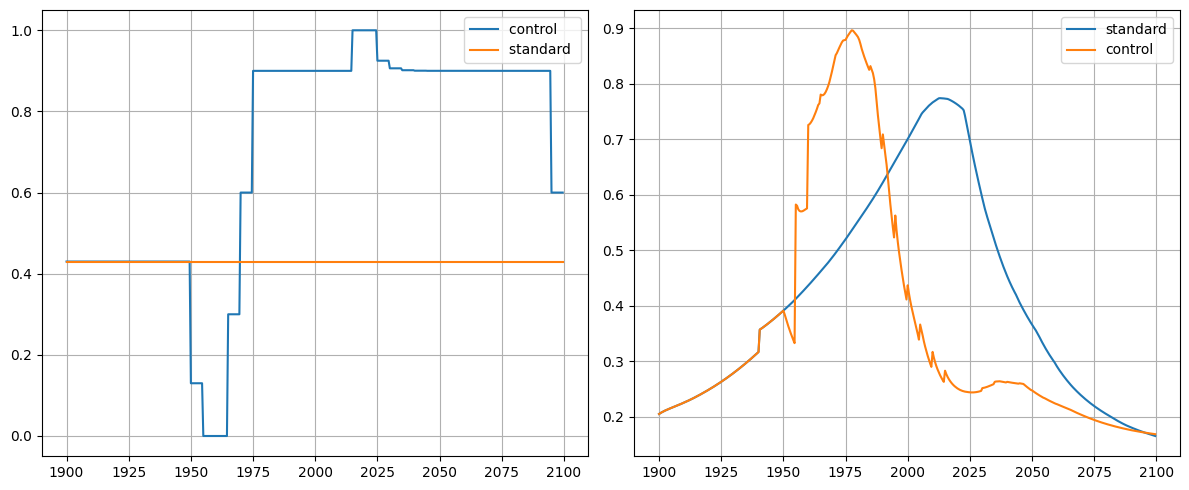

(None, <matplotlib.legend.Legend at 0x17c9d9775b0>, None, None)

In [16]:
start = 0
end = -1
plt.figure(figsize=(12, 5)), plt.subplot(1, 2, 1)
#plt.plot(world_reference.time[start:end], world_reference.fioac[start:end], label="standard fioac")
plt.plot(world_control.time[start:end], world_control.fioac[start:end], label="control ")
plt.plot(world_reference.time[start:end], world_reference.fioac[start:end], label="standard ")
#plt.plot(world_control.time[start:end], world_control.nr[start:end], label="control isopc")
plt.grid(), plt.legend(), plt.subplot(1, 2, 2)
plt.plot(world_reference.time[start:end], reward_func(world_reference)[start:end], label="standard")
plt.plot(world_control.time[start:end], reward_func(world_control)[start:end], label="control")
#plt.plot(world_reference.time[start:end], world_reference.ppol[start:end], label="standard")
#plt.plot(world_control.time[start:end], world_control.ppol[start:end], label="control")
plt.grid(), plt.legend(), plt.tight_layout(), plt.show()

In [ ]:
def standard_run_from(world, k):
    initial_state = {}
    for var in state_variables:
        if var in no_init_vars:
            continue
        val = getattr(world, var)[k]
        initial_state[var+"i"] = val

    world_temp = World3(year_min=MIN_YEAR, year_max=MAX_YEAR, year_min=world.time[k])
    world_temp.set_world3_control()
    world_temp.init_world3_constants(**initial_state)
    world_temp.init_world3_variables()
    world_temp.set_world3_table_functions()
    world_temp.set_world3_delay_functions()
    world_temp.run_world3(fast=False) # want fast=True

    J_ = J_func(reward_func(world_temp)) # this can probably be more dynamic
    return J_[0] # only want the first value

The following cell takes a while (around 25 minutes) to run.

In [18]:
time = world_control.time

J_control = J_func(reward_func(world_control)) # This can probably be more dynamic
J_standard = J_func(reward_func(world_reference))
nn_control = np.zeros((world_control.n,1))
nn_standard = np.zeros((world_reference.n,1))
standard_on_control = np.zeros((world_control.n,1))

for k in range(0, world_control.n):
    standard_on_control[k] = standard_run_from(world_control, k)
    nn_control[k] = nn_func(model, world_control, k)
    nn_standard[k] = nn_func(model, world_reference, k)

nrur 0:
282625000.00000006
nr 0:
1000000000000.0
nrur 0:
288303831.07459104
nr 0:
999858687500.0
nrur 0:
293976080.95266694
nr 0:
999715141346.4448
nrur 0:
299671177.8471226
nr 0:
999568941616.9462
nrur 0:
305409179.94976896
nr 0:
999419823452.091
nrur 0:
311200515.9662104
nr 0:
999267645973.668
nrur 0:
317041530.4643198
nr 0:
999112412480.7128
nrur 0:
322931381.05191
nr 0:
998954122172.8389
nrur 0:
328871222.87568164
nr 0:
998792769855.0717
nrur 0:
334863628.8249607
nr 0:
998628345867.7812
nrur 0:
340902977.30779475
nr 0:
998460914053.3688
nrur 0:
346992907.97785187
nr 0:
998290462564.7148
nrur 0:
353138600.4498988
nr 0:
998116966110.726
nrur 0:
359345304.806655
nr 0:
997940396810.501
nrur 0:
365618238.042177
nr 0:
997760724158.0977
nrur 0:
371962525.7874008
nr 0:
997577915039.0765
nrur 0:
378383171.7492881
nr 0:
997391933776.1829
nrur 0:
384885044.06625575
nr 0:
997202742190.3082
nrur 0:
391472871.93682224
nr 0:
997010299668.2751
nrur 0:
398151248.4258988
nr 0:
996814563232.3068
nrur

## Plot results

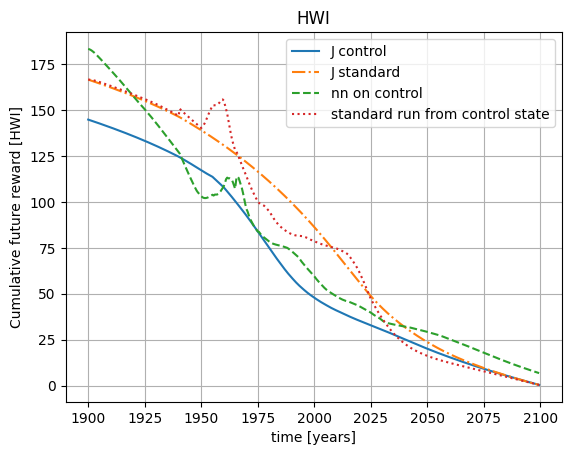

In [19]:
start = 0
end = -1

plt.plot(time[start:end], J_control[start:end], label="J control")
plt.plot(time[start:end], J_standard[start:end], label="J standard", linestyle='-.')
plt.plot(time[start:end], nn_control[start:end], label="nn on control", linestyle='--')
plt.plot(time[start:end], standard_on_control[start:end], label="standard run from control state", linestyle=':')
#plt.plot(time[start:end], nn_standard[start:end], label="nn on standard", linestyle='-.')
plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward [{reward_name}]")
plt.title(f"{reward_name}")
plt.legend()
plt.grid()
plt.savefig(f"plots/{reward_name}_J")
plt.show()

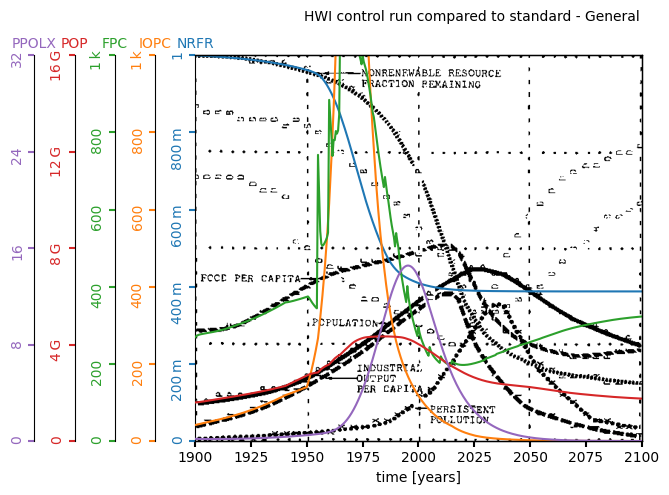

In [20]:
from pyworld3.utils import plot_world_variables
plot_world_variables(
    world_control.time,
    [world_control.nrfr, world_control.iopc, world_control.fpc, world_control.pop, world_control.ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title=f"{reward_name} control run compared to standard - General",
)
plt.savefig(f"plots/{reward_name}_general")
plt.show()

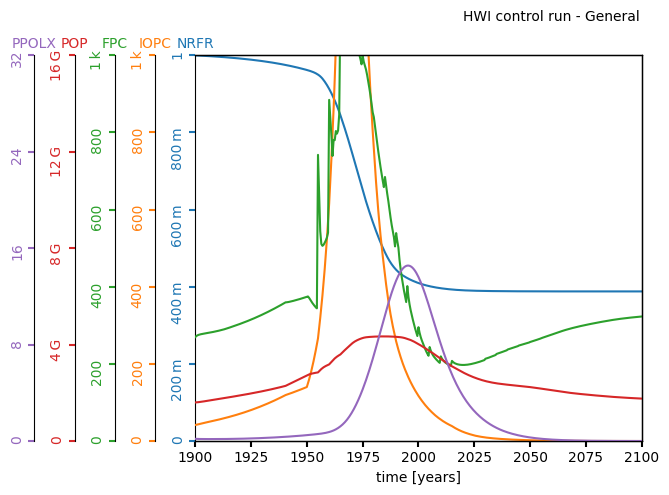

In [21]:
plot_world_variables(
    world_control.time,
    [world_control.nrfr, world_control.iopc, world_control.fpc, world_control.pop, world_control.ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    figsize=(7, 5),
    title=f"{reward_name} control run - General",
)
plt.savefig(f"plots/{reward_name}_general_nobackground")
plt.show()

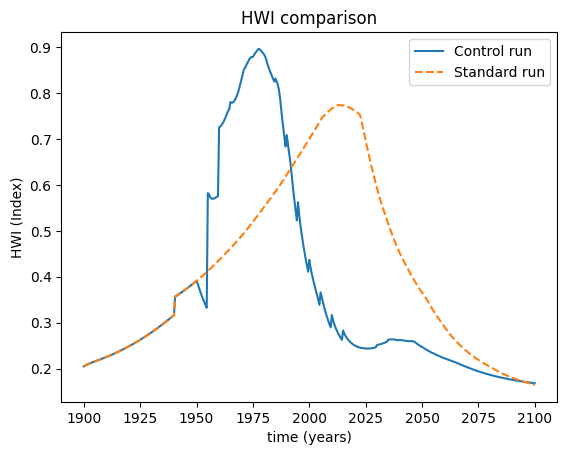

In [22]:
plt.plot(time, reward_func(world_control), label="Control run")
plt.plot(time, reward_func(world_reference), label="Standard run", linestyle='--')
plt.xlabel("time (years)")
plt.legend()
plt.ylabel(f"{reward_name} (Index)")
plt.title(f"{reward_name} comparison")
plt.savefig(f"plots/{reward_name}_comparison")

In [ ]:
plt.figure(figsize=(12, 5)), plt.subplot(1, 2, 1)
#plt.plot(world_reference.time[start:end], world_reference.fioac[start:end], label="standard fioac")
plt.plot(world_control.time, world_control.fioac)
#plt.plot(world_control.time[start:end], world_control.nr[start:end], label="control isopc")
plt.grid(), 
plt.ylabel("Control value"), 
plt.xlabel("time [years]") 
plt.title("FIOAC")
plt.tight_layout()
plt.subplot(1, 2, 2)

plt.plot(world_reference.time, world_control.isopc_control_values)
#plt.plot(world_reference.time[start:end], world_reference.ppol[start:end], label="standard")
#plt.plot(world_control.time[start:end], world_control.ppol[start:end], label="control")
plt.grid(), 
plt.ylabel("Control value"), 
plt.xlabel("time [years]") 
plt.title("ISOPC")
plt.tight_layout(),
plt.savefig(f"plots/{reward_name}_controls")
plt.show()

In [ ]:
plot_world_variables(
    world_control.time,
    [
        world_control.iopc,
        world_control.sopc,
        world_control.j / world_control.pop
    ],
    ["IOPC", "SOPC", "J/POP"],
    [[0, 4e3], [0, 4e3]],
    #img_background="./img/fig7-8.png",
    figsize=(7, 5),
    title=f"{reward_name} control run - Capital sector",
)
plt.savefig(f"plots/{reward_name}_capital_sector")

In [ ]:
plot_world_variables( # Dint think we need this one
    world_control.time,
    [world_control.sopc, world_control.iopc, world_control.le, world_control.ppolx, world_control.j/world_control.pop],
    ["SOPC", "IOPC", "LE", "PPOLX", "J/POP"],
    [[0, 8e2], [0, 8e2], [0,80], [0,2e9], [0,1]],
    figsize=(7, 5),
    title=f"{reward_name} control run - rewards",
)